# 1. IMPORTS

In [1]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from collections import Counter
from datetime import datetime
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import emoji

warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
plt.style.use('ggplot')
%matplotlib inline

In [3]:
# Load dữ liệu
parts = [pd.read_parquet(f'/content/guardian_part{i}.parquet') for i in range(1, 7)]
df = pd.concat(parts, ignore_index=True)

# Kiểm tra sơ bộ
print(f"Kích thước tập dữ liệu gốc: {df.shape}")
print("Thông tin NULL các cột:\n", df.isnull().sum())
print(df['scrape_status'].value_counts())

Kích thước tập dữ liệu gốc: (39138, 5)
Thông tin NULL các cột:
 url              0
label            0
article          0
title            0
scrape_status    0
dtype: int64
scrape_status
success    39138
Name: count, dtype: int64


In [4]:
df.drop(columns=['scrape_status'], inplace=True)

# 2. KIỂM TRA TRÙNG LẶP (Data Leakage Risk)


In [5]:
duplicates = df[df.duplicated(subset=['article'], keep=False)]
num_duplicates = len(duplicates)

print(f"Số lượng dòng trùng lặp: {num_duplicates}")

if num_duplicates > 0:
    print("\nPhân phối trùng lặp theo nhãn (Label):")
    print(duplicates['label'].value_counts())

Số lượng dòng trùng lặp: 451

Phân phối trùng lặp theo nhãn (Label):
label
film           100
music           86
food            67
sport           54
games           38
environment     28
culture         26
science         18
money           12
fashion         12
technology       8
business         2
Name: count, dtype: int64


In [6]:
print(f"Số lượng trước khi xử lý trùng lặp: {len(df)}")
df = df.drop_duplicates(subset=['article'], keep='first')
print(f"Số lượng sau khi xử lý: {len(df)}")

Số lượng trước khi xử lý trùng lặp: 39138
Số lượng sau khi xử lý: 38907


# 3. PHÂN TÍCH PHÂN PHỐI NHÃN (Category Analysis)


Số lượng categories: 13
Tỷ lệ mất cân bằng (Largest/Smallest): 5.12:1


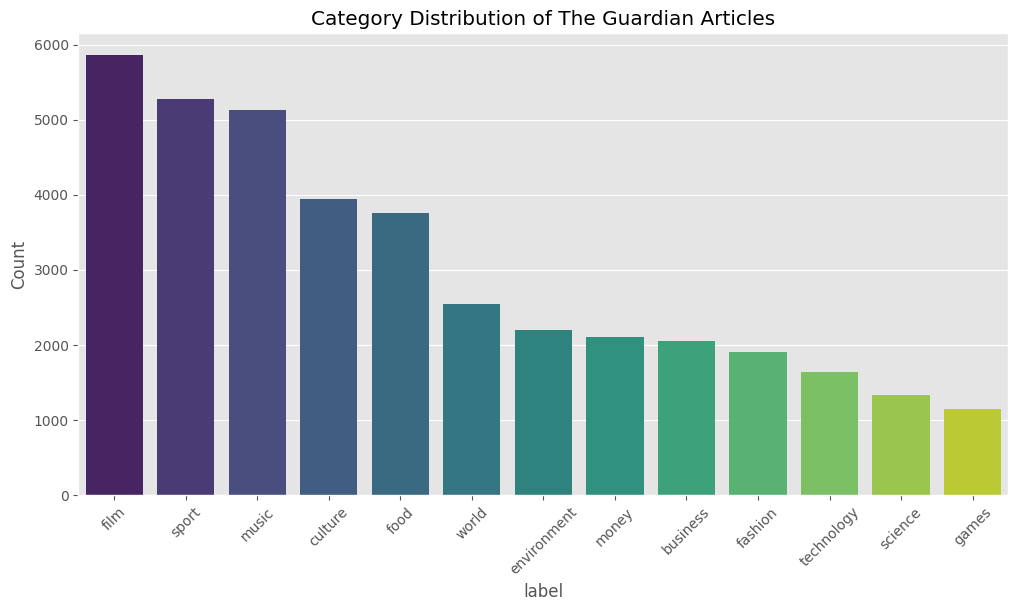

In [7]:
category_counts = df['label'].value_counts()
imbalance_ratio = category_counts.max() / category_counts.min()

print(f"\nSố lượng categories: {len(category_counts)}")
print(f"Tỷ lệ mất cân bằng (Largest/Smallest): {imbalance_ratio:.2f}:1")

# Vẽ biểu đồ phân phối
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Category Distribution of The Guardian Articles')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

# 4. CHIA DỮ LIỆU (Split Strategy)

In [8]:
label_mapping = {
    'business': 'business_finance',
    'money': 'business_finance',
    'world': 'world_environment',
    'environment': 'world_environment',
    'culture': 'culture_lifestyle',
    'fashion': 'culture_lifestyle',
    'technology': 'tech_science_games',
    'science': 'tech_science_games',
    'games': 'tech_science_games',
    'sport': 'sport',
    'film': 'film',
    'music': 'music',
    'food': 'food'
}

# Tạo một cột label mới đã gộp
df['label'] = df['label'].map(label_mapping)

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print("\n--- PHƯƠNG PHÁP CHIA THEO NHÃN GỘP ---")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

dist = pd.DataFrame({
    'Gốc': df['label'].value_counts(normalize=True) * 100,
    'Train': train_df['label'].value_counts(normalize=True) * 100,
    'Val': val_df['label'].value_counts(normalize=True) * 100,
    'Test': test_df['label'].value_counts(normalize=True) * 100
})
print("\nTỷ lệ nhãn (%):")
print(dist.round(2))


--- PHƯƠNG PHÁP CHIA THEO NHÃN GỘP ---
Train: 27234 | Val: 5836 | Test: 5837

Tỷ lệ nhãn (%):
                      Gốc  Train    Val   Test
label                                         
film                15.05  15.05  15.04  15.06
culture_lifestyle   15.03  15.03  15.03  15.04
sport               13.57  13.57  13.57  13.57
music               13.19  13.19  13.18  13.19
world_environment   12.21  12.21  12.22  12.20
business_finance    10.72  10.71  10.73  10.71
tech_science_games  10.57  10.57  10.57  10.57
food                 9.66   9.66   9.66   9.66



Số lượng categories: 8
Tỷ lệ mất cân bằng (Largest/Smallest): 1.56:1


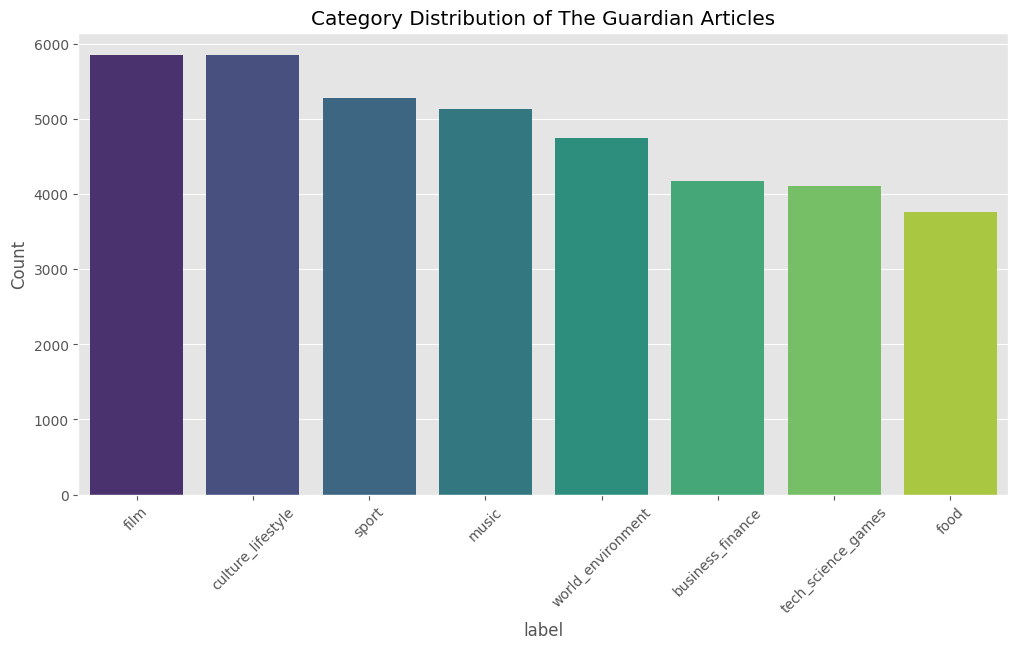

In [10]:
category_counts = df['label'].value_counts()
imbalance_ratio = category_counts.max() / category_counts.min()

print(f"\nSố lượng categories: {len(category_counts)}")
print(f"Tỷ lệ mất cân bằng (Largest/Smallest): {imbalance_ratio:.2f}:1")

# Vẽ biểu đồ phân phối
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Category Distribution of The Guardian Articles')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

In [11]:
del df

In [12]:
train_df[['label', 'article', 'title']].to_parquet('train.parquet', index=False)
val_df[['label', 'article', 'title']].to_parquet('val.parquet', index=False)
test_df[['label', 'article', 'title']].to_parquet('test.parquet', index=False)

# 5. PHÂN TÍCH ĐẶC TRƯNG ĐỘ DÀI VĂN BẢN

In [13]:
def get_text_features(text):
    if pd.isna(text):
        return pd.Series([0, 0, 0])

    # Chuyển về chữ thường và loại bỏ dấu câu cơ bản để đếm từ chuẩn hơn
    text = str(text).lower()
    words = re.findall(r'\w+', text) # Chỉ lấy các ký tự chữ và số

    chars = len(str(text))
    word_count = len(words)
    unique_words = len(set(words))

    lexical_diversity = unique_words / word_count if word_count > 0 else 0

    return pd.Series([word_count, chars, lexical_diversity])

In [14]:
train_df["title_article"] = train_df["title"] + " . " + train_df["article"]

In [15]:
train_df[['word_count', 'char_length', 'unique_word_ratio']] = train_df['title_article'].apply(get_text_features)

# Thống kê mô tả
stats_summary = train_df[['word_count', 'char_length', 'unique_word_ratio']].agg(['min', 'mean', 'median', 'std', 'max']).T
print("Key Text Feature Statistics:")
print(stats_summary)

Key Text Feature Statistics:
                          min         mean      median          std  \
word_count          23.000000   785.742601   676.00000   521.914480   
char_length        129.000000  4533.349196  3928.00000  2970.265075   
unique_word_ratio    0.200551     0.509044     0.50102     0.084116   

                            max  
word_count          7465.000000  
char_length        43464.000000  
unique_word_ratio      0.962963  


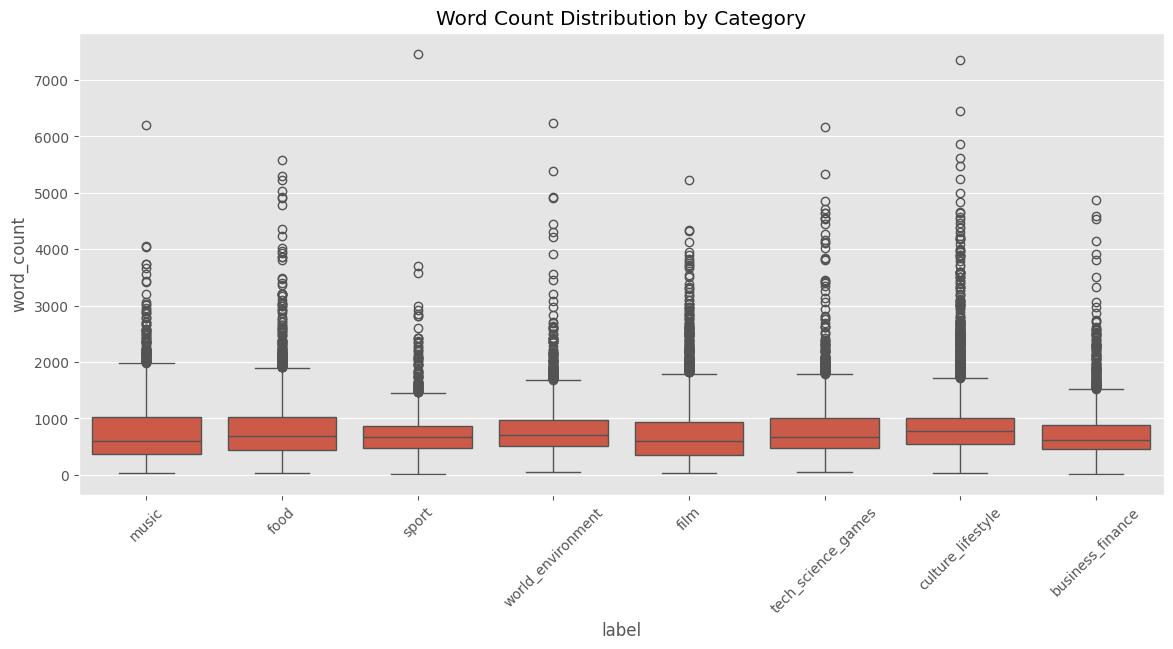

In [16]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=train_df, x='label', y='word_count')
plt.title('Word Count Distribution by Category')
plt.xticks(rotation=45)
plt.show()

In [17]:
# Kiểm tra bài viết quá ngắn
short_articles = train_df[train_df['word_count'] < 50]
print(f"Số lượng bài viết < 100 từ: {len(short_articles)}")
short_articles[['title_article', 'url']].head()

Số lượng bài viết < 100 từ: 34


,title_article,url
12538,"Sports quiz of the week: Gareth Bale, a glut o...",https://www.theguardian.com/sport/2020/sep/18/...
32694,Guardian business Christmas quiz 2023 . Do you...,https://www.theguardian.com/business/2023/dec/...
7555,Never mind the ballads! How bardcore took over...,https://www.theguardian.com/music/2020/jun/24/...
8211,Quiz: how much do you really know about the Os...,https://www.theguardian.com/film/2020/feb/04/q...
34710,Sport quiz of the year: test your knowledge of...,https://www.theguardian.com/sport/2023/dec/26/...


# 6. PHÂN TÍCH NHIỄU (Boilerplate & N-Grams)

In [18]:
# Đếm tần suất từ xuất hiện (Bag of Words)
vectorizer = CountVectorizer(stop_words='english', binary=True)
X = vectorizer.fit_transform(train_df['article'].astype(str))
df_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'doc_count': np.asarray(X.sum(axis=0)).ravel()
})
df_counts['percentage'] = (df_counts['doc_count'] / len(train_df)) * 100
print("Top 20 từ phổ biến nhất:")
print(df_counts.sort_values(by='percentage', ascending=False).head(20))

Top 20 từ phổ biến nhất:
              word  doc_count  percentage
158640        time      16066   58.992436
137072        said      15554   57.112433
175134        year      15116   55.504149
92926         like      14920   54.784461
109802         new      14671   53.870162
84155         just      14424   52.963208
119352      people      12928   47.470074
175148       years      12687   46.585151
173882       world      11415   41.914519
168384        view      11397   41.848425
96930         make      11324   41.580377
170924         way      11091   40.724829
77809        image      10918   40.089594
62641   fullscreen      10452   38.378497
120673  photograph       9873   36.252479
173798        work       9636   35.382243
48284          don       9213   33.829037
94270         long       9205   33.799662
67107         good       8891   32.646692
42932          day       8713   31.993097


In [19]:
# Phân tích Trigram để tìm cụm từ rác cố định
def get_top_ngrams(corpus, n=None, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

print("\nTop 30 Trigrams:")
common_phrases = get_top_ngrams(train_df['article'], n=3, top_k=30)
for phrase, freq in common_phrases:
    percentage = (freq / len(train_df)) * 100
    print(f"{phrase}: {freq} ({percentage:.1f}%)")


Top 30 Trigrams:
view image in: 24339 (89.4%)
image in fullscreen: 24339 (89.4%)
one of the: 9420 (34.6%)
as well as: 5482 (20.1%)
the end of: 4114 (15.1%)
in the uk: 3922 (14.4%)
some of the: 3200 (11.8%)
part of the: 3050 (11.2%)
the first time: 3022 (11.1%)
double quotation mark: 2886 (10.6%)
out of the: 2700 (9.9%)
be able to: 2584 (9.5%)
in the us: 2512 (9.2%)
in the world: 2490 (9.1%)
for the first: 2352 (8.6%)
going to be: 2269 (8.3%)
of the most: 2258 (8.3%)
according to the: 2239 (8.2%)
at the time: 2143 (7.9%)
end of the: 2123 (7.8%)
at the end: 2112 (7.8%)
in fullscreen the: 2047 (7.5%)
is one of: 2041 (7.5%)
the rest of: 2009 (7.4%)
in the first: 1929 (7.1%)
of the world: 1869 (6.9%)
of the year: 1855 (6.8%)
the fact that: 1844 (6.8%)
if you re: 1808 (6.6%)
as part of: 1789 (6.6%)


In [20]:
def eda_text_noise(df, text_col='article', url_col='url'):
    # Danh sách các pattern kiểm tra
    patterns = {
        "URL (Link web)": r'https?://\S+|www\.\S+',
        "Twitter Media": r'pic\.twitter\.com/\S+',
        "Email": r'\S+@\S+',
        "Social Mentions (@)": r'@\S+',
        "Smart Quotes/Dashes (Ký tự đặc biệt)": r'[“”‘’—–]',
        "Non-ASCII (Ký tự lạ/Emoji)": r'[^\x00-\x7F]',
        "Excess Whitespace (Khoảng trắng thừa)": r'\s{2,}'
    }

    print(f"{'='*40} BÁO CÁO PHÂN TÍCH NHIỄU {'='*40}\n")

    for name, pattern in patterns.items():
        # Lọc các dòng chứa nhiễu
        if name == "Non-ASCII (Ký tự lạ/Emoji)":
            mask = df[text_col].apply(lambda x: any(ord(char) > 127 for char in str(x)))
        else:
            mask = df[text_col].str.contains(pattern, regex=True, na=False)

        matches = df[mask]
        count = len(matches)

        print(f"🔍 LOẠI NHIỄU: {name}")
        print(f"📊 Tổng số dòng phát hiện: {count} (~{(count/len(df)*100):.2f}%)")

        if count > 0:
            # Lấy mẫu 2 dòng bao gồm cả cột URL và TEXT
            n_sample = min(count, 2)
            samples = matches[[url_col, text_col]].sample(n_sample)

            for i, (idx, row) in enumerate(samples.iterrows()):
                # Format text để in ra đẹp hơn
                original_text = str(row[text_col]).replace('\n', ' ').strip()
                display_text = original_text

                print(f"   👉 Mẫu {i+1}:")
                print(f"      🔗 URL: {row[url_col]}")
                print(f"      📝 Text: {display_text}")
        else:
            print("   ✅ Sạch! Không tìm thấy.")

        print("-" * 100)

In [21]:
eda_text_noise(train_df)

======================================== BÁO CÁO PHÂN TÍCH NHIỄU ========================================

🔍 LOẠI NHIỄU: URL (Link web)
📊 Tổng số dòng phát hiện: 308 (~1.13%)
   👉 Mẫu 1:
      🔗 URL: https://www.theguardian.com/film/2020/sep/07/disney-remake-of-mulan-criticised-for-filming-in-xinjiang
      📝 Text: Disney’s live-action remake of Mulan, already the target of a boycott, has come under fire for filming in Xinjiang, the site of alleged widespread human rights abuses against Uighurs and other Muslim minorities.  The film, directed by Niki Caro, is an adaptation of Disney’s 1998 animation about Hua Mulan, a young woman who disguises herself as a man to fight in the imperial army in her father’s stead.  The remake attracted criticism when the actor Liu Yifei, who plays Mulan, said she supported Hong Kong police in their often violent crackdowns on pro-democracy protesters.  After the film’s release last Friday, observers noted another controversial element: in the final credi

# 7. DATA CLEANING

In [22]:
def clean_guardian_text(text):
    if not isinstance(text, str) or text == "":
        return ""

    # --- 1. THAY THẾ CỤM TỪ ĐẶC BIỆT ---
    # BẰNG CHỨNG: Trigram 'double quotation mark' chiếm 10.6%.
    # Đây là lỗi khi crawl các đoạn trích dẫn nổi bật (pull quotes) của The Guardian.
    text = text.replace("double quotation mark", '"')

    # --- 2. XỬ LÝ THEO ĐOẠN (Dựa trên \n\n) ---
    # Việc tách theo \n\n giúp lọc bỏ chính xác các block rác như Caption hoặc Newsletter
    # mà không lo lắng về việc xóa nhầm nội dung trong câu.
    blocks = text.split('\n\n')
    cleaned_blocks = []

    # Các mẫu nhiễu được xác định từ thống kê Trigrams và phân tích thủ công
    noise_patterns = [
        r"View image in fullscreen", # Top 1 Trigram (89.4%)
        r"Photograph:.*?(Getty|Alamy|Reuters|AP|Guardian|PA|Images)", # Top từ phổ biến
        r"(?i)Sign up (to|for) (the )?.*?newsletter", # Newsletter CTA
        r"(?i)Sign up to (the )?.*?email",
        r"(?i)The Breakdown: sign up",
        r"(?i)Follow .*? on Twitter",
        r"Was this helpful\? Thank you for your feedback", # UI Web
        r"If you.re having trouble using the form", # Form liên hệ
        r"(?i)Reuters and Associated Press contributed", # Tín dụng thông tấn
        r"Include an address and phone number" # Yêu cầu tòa soạn
    ]

    for block in blocks:
        block = block.strip()
        if not block:
            continue

        # Lọc nhiễu theo Pattern
        is_noise = False
        for pattern in noise_patterns:
            if re.search(pattern, block):
                is_noise = True
                break

        if is_noise:
            continue

        # Lọc theo độ dài: Các block quá ngắn (< 30 ký tự) không có dấu kết thúc
        # thường là tên phóng viên hoặc địa danh (London, Sydney...).
        if len(block) < 30 and not block.endswith(('.', '!', '?', '"', "'",':')):
            continue

        cleaned_blocks.append(block)

    # Gộp lại bằng dấu cách hoặc \n tùy vào mục đích (ở đây dùng dấu cách để đồng nhất text)
    text = " ".join(cleaned_blocks)

    # --- 3. XÓA URL, EMAIL, SOCIAL ---
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'pic\.twitter\.com/\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'@\S+', '', text) # Xóa các handle như @BusinessDesk
    text = re.sub(r'#(\w+)', r'\1', text)  # #ClimateChange → ClimateChange


    # --- 4. CHUẨN HÓA UNICODE VÀ ASCII ---
    # Chuyển đổi Smart Quotes về ASCII để tránh việc 'don't' bị hiểu thành 'don' và 't'
    text = text.replace('“', '"').replace('”', '"').replace('‘', "'").replace('’', "'")
    text = text.replace('—', '-').replace('–', '-').replace('…', '...')

    # Xóa Emoji
    text = emoji.replace_emoji(text, replace='')

    # Chuẩn hóa Unicode + Bỏ accents (NFKD)
    text = unicodedata.normalize('NFKD', text)

    allowed_symbols = r'[€£¥₿]'
    text = re.sub(rf'[^\x00-\x7F{allowed_symbols}]', ' ', text)

    # Chuẩn hóa khoảng trắng và lowercase (không bắt buộc vì uncased sẽ lowercase)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [23]:
train = pd.read_parquet('/content/train.parquet')
val = pd.read_parquet('/content/val.parquet')
test = pd.read_parquet('/content/test.parquet')

In [24]:
train_clean = train.copy()
val_clean = val.copy()
test_clean = test.copy()

train_clean['article'] = train_clean['article'].apply(clean_guardian_text)
val_clean['article'] = val_clean['article'].apply(clean_guardian_text)
test_clean['article'] = test_clean['article'].apply(clean_guardian_text)

In [25]:
train_clean.to_parquet('train_clean.parquet', index=False)
val_clean.to_parquet('val_clean.parquet', index=False)
test_clean.to_parquet('test_clean.parquet', index=False)